# Stage 1

## 2.1 The return objects

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

dforigin = pd.read_parquet("prices.parquet", engine="pyarrow")
df = dforigin.copy()
df = df.drop_duplicates(subset=["instrument_id", "date"]).copy()
df.head()

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status,updated
0,XEL,2,2000-01-03,19.625,19.6250,18.9375,19.0000,6.5292,2738600.0,1.271214e+09,1,2025-10-28 10:09:30
1,ED,3,2000-01-03,34.375,34.4375,33.7500,33.7500,10.3796,581900.0,7.331932e+09,1,2025-10-28 10:09:30
2,BBY,4,2000-01-03,57.750,57.8751,54.0000,57.5001,13.8958,19512431.0,1.180305e+10,1,2025-10-28 10:09:30
3,DVN,6,2000-01-03,33.125,33.5000,32.0625,32.3750,9.6808,717600.0,2.787002e+09,1,2025-10-28 10:09:30
4,CVX,12,2000-01-03,85.875,85.8750,82.5626,83.6250,15.7215,4387600.0,5.488021e+10,1,2025-10-28 10:09:30


In [2]:
# Set time
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["instrument_id", "date"]).copy()
# remove 2001.9.11, a wrong data
df = df[df['date'] != '2001-09-11']
df["adj_factor"] = df["adjusted_close"] / df["close"]
df["open_adj"] = (df["open"] - df["close"]) * df["adj_factor"] + df["adjusted_close"]
df["close_adj"] = df["adjusted_close"]
df["volume_adj"] = df["volume"] / df["adj_factor"]
df["close_adj_lag1"] = df.groupby("instrument_id")["close_adj"].shift(1)

df["r_on"] = df["open_adj"] / df["close_adj_lag1"] - 1
df["r_id"] = df["close_adj"] / df["open_adj"] - 1
df["r_cc"] = df["close_adj"] / df["close_adj_lag1"] - 1
df

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status,updated,adj_factor,open_adj,close_adj,volume_adj,close_adj_lag1,r_on,r_id,r_cc
3846661,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,41.6951,23716568.0,2.116608e+10,1,2025-10-28 10:09:30,1.939596,41.307375,41.6951,1.222758e+07,NaN,NaN,0.009386,NaN
3847967,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,42.8587,3984417.0,2.175675e+10,1,2025-10-28 10:09:30,1.939597,42.645538,42.8587,2.054250e+06,41.6951,0.022795,0.004998,0.027907
3849273,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,41.7339,3226908.0,2.118577e+10,1,2025-10-28 10:09:30,1.939596,44.856262,41.7339,1.663701e+06,42.8587,0.046608,-0.069608,-0.026244
3850578,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,42.2963,1584449.0,2.147131e+10,1,2025-10-28 10:09:30,1.939592,41.908382,42.2963,8.168980e+05,41.7339,0.004181,0.009256,0.013476
3851884,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,42.3351,1955194.0,2.149100e+10,1,2025-10-28 10:09:30,1.939593,42.335100,42.3351,1.008044e+06,42.2963,0.000917,0.000000,0.000917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7993852,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,43.6100,49800.0,1.638719e+09,1,2026-04-10 16:44:01,1.000000,43.250000,43.6100,4.980000e+04,43.3000,-0.001155,0.008324,0.007159
7995479,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,43.5600,95500.0,1.636840e+09,1,2026-04-10 16:44:01,1.000000,42.970000,43.5600,9.550000e+04,43.6100,-0.014676,0.013731,-0.001147
7997108,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,42.9400,94400.0,1.613543e+09,1,2026-04-10 16:44:01,1.000000,43.310000,42.9400,9.440000e+04,43.5600,-0.005739,-0.008543,-0.014233
7998737,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,42.7900,70900.0,1.607906e+09,1,2026-04-10 16:44:01,1.000000,42.730000,42.7900,7.090000e+04,42.9400,-0.004891,0.001404,-0.003493


In [3]:
# reconciliation
df["recon_lhs"] = (1 + df["r_on"]) * (1 + df["r_id"]) - 1
df["recon_error"] = df["recon_lhs"] - df["r_cc"]
df["abs_recon_error"] = df["recon_error"].abs()
# tolerance 1e-8, the maximum error is far below
df["abs_recon_error"].max()

1.4210854715202004e-14

In [4]:
# Rename the column
df = df.rename(columns={"open_adj": "Open_t","close_adj": "Close_t","volume_adj": "Volume_t"})
df = df[["ticker","instrument_id", "date", "market_cap", "Open_t", "Close_t", "Volume_t", "adj_factor",
        "r_on", "r_id", "r_cc"]].copy()
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
df21 = df.copy()
df21

,ticker,instrument_id,date,market_cap,Open_t,Close_t,Volume_t,adj_factor,r_on,r_id,r_cc
0,A,256,2000-01-03,3.146396e+10,46.961643,42.9363,7.838425e+06,0.596338,NaN,-0.085716,NaN
1,A,256,2000-01-04,2.906054e+10,40.625489,39.6565,7.990582e+06,0.596337,-0.053820,-0.023852,-0.076388
2,A,256,2000-01-05,2.725788e+10,39.507411,37.1966,9.656670e+06,0.596338,-0.003760,-0.058491,-0.062030
3,A,256,2000-01-06,2.622004e+10,36.749289,35.7803,4.250001e+06,0.596337,-0.012026,-0.026368,-0.038076
4,A,256,2000-01-07,2.840500e+10,35.221300,38.7620,4.728231e+06,0.596338,-0.015623,0.100527,0.083334
...,...,...,...,...,...,...,...,...,...,...,...
7883224,ZWS,1447,2024-12-24,6.418579e+09,37.041106,37.3871,2.843548e+05,0.988554,-0.000267,0.009341,0.009071
7883225,ZWS,1447,2024-12-26,6.457614e+09,37.120223,37.6145,5.480730e+05,0.988555,-0.007138,0.013316,0.006082
7883226,ZWS,1447,2024-12-27,6.399911e+09,37.278400,37.2784,5.069016e+05,0.988555,-0.008935,0.000000,-0.008935
7883227,ZWS,1447,2024-12-30,6.359180e+09,37.011443,37.0411,4.572337e+05,0.988554,-0.007161,0.000801,-0.006366


## 2.1.1 Auction conventions and the trader's clock 

Just remember not to use the information we don't know at trading. No actions needed.

## 2.1.2 Earnings dates and the timing flag (finish)

For those showing 'before', we assume the available date is the original reporting date. For those showing 'after', we assume the available date is the next trading date of original reporting date. For those showing 'None', they are Same-Day announcement, and we allow reporting time before 15:45 ET to be considered as available on that day, otherwise they will be availble on the next trading date. Here we have taken Daylight Saving Time (DST) into consideration.

In [5]:
dfearnings = pd.read_parquet("earnings_calendar.parquet", engine="pyarrow")
dfearnings["time"] = dfearnings["reporting_time"].astype(str).str.split().str[-1]
dfearnings = dfearnings.drop(columns=["strat_trading_date","reporting_time"])
dfearnings["reporting_date"] = pd.to_datetime(dfearnings["reporting_date"])
dfearnings

,stock_id,reporting_date,before_after_market,period,period_end_date,time
0,1,2014-02-27,before,FY2013Q4,2013-12-31,13:30:00
1,1,2014-05-09,before,FY2014Q1,2014-03-31,12:30:00
2,1,2014-08-01,before,FY2014Q2,2014-06-30,12:30:00
3,1,2014-10-31,before,FY2014Q3,2014-09-30,12:30:00
4,1,2015-02-18,before,FY2014Q4,2014-12-31,13:30:00
...,...,...,...,...,...,...
60917,1612,2023-11-09,before,FY2023Q3,2023-09-30,12:02:03
60918,1612,2024-02-14,before,FY2023Q4,2023-12-31,12:00:06
60919,1612,2024-05-02,before,FY2024Q1,2024-03-31,12:30:00
60920,1612,2024-08-07,before,FY2024Q2,2024-06-30,11:00:09


In [6]:
# 19:45-20:00 is not available, 20:45-21:00 also for DST
dfearnings["time"] = pd.to_datetime(dfearnings["time"], format="%H:%M:%S", errors="coerce").dt.time
mask_null = dfearnings["before_after_market"].isna()
dfearnings.loc[mask_null & (dfearnings["time"] >= pd.to_datetime("19:45:00").time()) &
         (dfearnings["time"] <= pd.to_datetime("20:00:00").time())]

,stock_id,reporting_date,before_after_market,period,period_end_date,time
6617,156,2022-02-24,None,FY2021Q4,2021-12-31,19:45:22
9365,220,2021-02-25,None,FY2021Q1,2021-01-31,19:54:53
17015,403,2023-11-01,None,FY2023Q3,2023-09-30,19:59:00
31394,783,2022-08-18,None,FY2022Q4,2022-06-30,19:59:59
42022,1068,2020-07-23,None,FY2020Q2,2020-06-30,19:51:50
52656,1354,2024-08-07,None,FY2024Q2,2024-06-30,19:53:50


In [7]:
# November-March is winter time zone, market closes on 21:00
# row 6617, 9365 are flagged "before", 
# row 17015, 31394, 42022, 52656 are flagged "after"
dfearnings["time"] = pd.to_datetime(dfearnings["time"], format="%H:%M:%S", errors="coerce").dt.time
mask_null = dfearnings["before_after_market"].isna()
dfearnings.loc[
    mask_null &
    (
        ((dfearnings["time"] >= pd.to_datetime("19:45:00").time()) &
         (dfearnings["time"] <= pd.to_datetime("20:00:00").time())) |
        ((dfearnings["time"] >= pd.to_datetime("20:45:00").time()) &
         (dfearnings["time"] <= pd.to_datetime("21:00:00").time()))
    ),
    "before_after_market"
] = "after"
dfearnings.loc[
    mask_null & dfearnings["before_after_market"].isna(),
    "before_after_market"
] = "before"
dfearnings.loc[
    [6617, 9365],
    "before_after_market"
] = "before"
dfearnings

,stock_id,reporting_date,before_after_market,period,period_end_date,time
0,1,2014-02-27,before,FY2013Q4,2013-12-31,13:30:00
1,1,2014-05-09,before,FY2014Q1,2014-03-31,12:30:00
2,1,2014-08-01,before,FY2014Q2,2014-06-30,12:30:00
3,1,2014-10-31,before,FY2014Q3,2014-09-30,12:30:00
4,1,2015-02-18,before,FY2014Q4,2014-12-31,13:30:00
...,...,...,...,...,...,...
60917,1612,2023-11-09,before,FY2023Q3,2023-09-30,12:02:03
60918,1612,2024-02-14,before,FY2023Q4,2023-12-31,12:00:06
60919,1612,2024-05-02,before,FY2024Q1,2024-03-31,12:30:00
60920,1612,2024-08-07,before,FY2024Q2,2024-06-30,11:00:09


In [8]:
calendar = pd.DataFrame(df['date'].drop_duplicates())
calendar["date"] = pd.to_datetime(calendar["date"])
calendar = calendar.sort_values("date").reset_index(drop=True)
next_day_map = dict(zip(calendar["date"], calendar["date"].shift(-1)))

mask_after = dfearnings["before_after_market"] == "after"
dfearnings['available_date'] = dfearnings['reporting_date']
dfearnings.loc[mask_after, "available_date"] = dfearnings.loc[mask_after, "reporting_date"].map(next_day_map)
dfearnings

,stock_id,reporting_date,before_after_market,period,period_end_date,time,available_date
0,1,2014-02-27,before,FY2013Q4,2013-12-31,13:30:00,2014-02-27
1,1,2014-05-09,before,FY2014Q1,2014-03-31,12:30:00,2014-05-09
2,1,2014-08-01,before,FY2014Q2,2014-06-30,12:30:00,2014-08-01
3,1,2014-10-31,before,FY2014Q3,2014-09-30,12:30:00,2014-10-31
4,1,2015-02-18,before,FY2014Q4,2014-12-31,13:30:00,2015-02-18
...,...,...,...,...,...,...,...
60917,1612,2023-11-09,before,FY2023Q3,2023-09-30,12:02:03,2023-11-09
60918,1612,2024-02-14,before,FY2023Q4,2023-12-31,12:00:06,2024-02-14
60919,1612,2024-05-02,before,FY2024Q1,2024-03-31,12:30:00,2024-05-02
60920,1612,2024-08-07,before,FY2024Q2,2024-06-30,11:00:09,2024-08-07


In [9]:
dfearnings = dfearnings.drop(columns=["reporting_date","before_after_market","time"])
df212 = dfearnings.copy()
df212

,stock_id,period,period_end_date,available_date
0,1,FY2013Q4,2013-12-31,2014-02-27
1,1,FY2014Q1,2014-03-31,2014-05-09
2,1,FY2014Q2,2014-06-30,2014-08-01
3,1,FY2014Q3,2014-09-30,2014-10-31
4,1,FY2014Q4,2014-12-31,2015-02-18
...,...,...,...,...
60917,1612,FY2023Q3,2023-09-30,2023-11-09
60918,1612,FY2023Q4,2023-12-31,2024-02-14
60919,1612,FY2024Q1,2024-03-31,2024-05-02
60920,1612,FY2024Q2,2024-06-30,2024-08-07


## 2.1.3 Short interest and its publication lag (finish)

In [10]:
dfinterest = pd.read_parquet("short_interest_transfo.parquet", engine="pyarrow").copy()
dfinterest["date"] = pd.to_datetime(dfinterest["date"])
dfinterest["stock_id"] = dfinterest["stock_id"].astype("Int64")

# + 10 
dfinterest["effective_raw"] = dfinterest["date"] + pd.Timedelta(days=10)


trading_dates = pd.Series(
    pd.to_datetime(df["date"]).drop_duplicates().sort_values().values
)


idx = trading_dates.searchsorted(dfinterest["effective_raw"].values, side="left")


valid = idx < len(trading_dates)
dfinterest["effective_date"] = pd.NaT
dfinterest.loc[valid, "effective_date"] = trading_dates.iloc[idx[valid]].values

In [11]:
dates = (
    df[["date"]]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)
dates["date"] = pd.to_datetime(dates["date"])

stocks = pd.DataFrame({
    "stock_id": dfinterest["stock_id"].drop_duplicates()
})

panel = stocks.merge(dates, how="cross")

signal = (
    dfinterest[["stock_id", "effective_date", "dsi", "dtcn", "ddtcn"]]
    .rename(columns={"effective_date": "date"})
)

panel = panel.merge(signal, on=["stock_id", "date"], how="left")
panel = panel.sort_values(["stock_id", "date"])

panel[["dsi", "dtcn", "ddtcn"]] = (
    panel.groupby("stock_id")[["dsi", "dtcn", "ddtcn"]].ffill()
)

panel = panel.dropna(subset=["dsi", "dtcn", "ddtcn"])

In [12]:
panel

,stock_id,date,dsi,dtcn,ddtcn
3797,1,2015-02-06,0.004074,1.669489,-0.245679
3798,1,2015-02-09,0.004074,1.669489,-0.245679
3799,1,2015-02-10,0.004074,1.669489,-0.245679
3800,1,2015-02-11,0.004074,1.669489,-0.245679
3801,1,2015-02-12,0.004074,1.669489,-0.245679
...,...,...,...,...,...
9999505,1612,2024-12-24,0.025500,7.443657,6.089679
9999506,1612,2024-12-26,0.025500,7.443657,6.089679
9999507,1612,2024-12-27,0.025500,7.443657,6.089679
9999508,1612,2024-12-30,0.025500,7.443657,6.089679


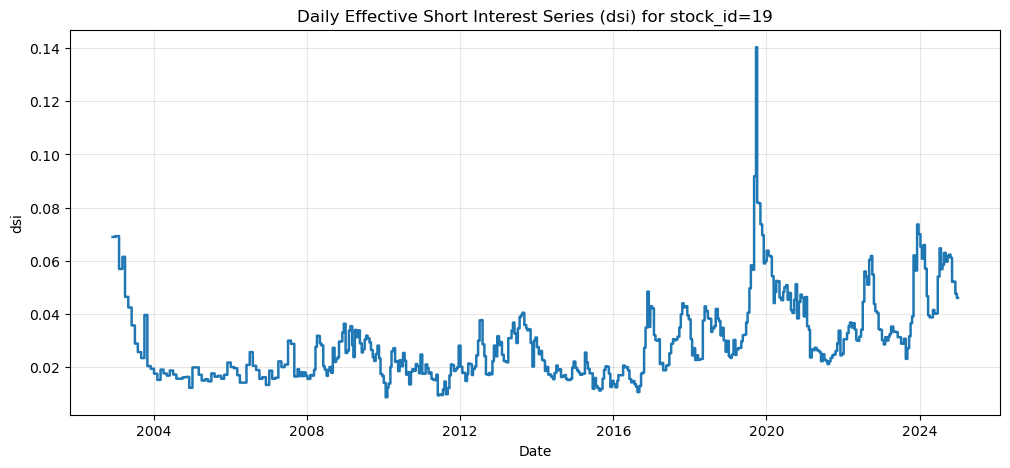

In [13]:
# representative name
rep_id = 19   

rep = panel[panel["stock_id"] == rep_id].copy()
rep = rep.sort_values("date")

plt.figure(figsize=(12, 5))
plt.plot(rep["date"], rep["dsi"], drawstyle="steps-post", linewidth=1.8)
plt.title(f"Daily Effective Short Interest Series (dsi) for stock_id={rep_id}")
plt.xlabel("Date")
plt.ylabel("dsi")
plt.grid(True, alpha=0.3)
plt.savefig("213.png", dpi=300, bbox_inches="tight")
plt.show()


In [14]:
df213 = panel.copy()

The panel here means the dsi, dtcn, ddtcn are available on the date which date_lag10 column shows.

## 2.1.4 Corporate actions, survivorship, and the universe at the time 

Just remember not to use future information to remove stocks selection in the past. Actions in 2.2

## 2.2 The investment universe — chosen yearly, held fixed within the year (finish)

In [15]:
df = dforigin.copy()
df = df.drop_duplicates(subset=["instrument_id", "date"]).copy()
df.head()

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status,updated
0,XEL,2,2000-01-03,19.625,19.6250,18.9375,19.0000,6.5292,2738600.0,1.271214e+09,1,2025-10-28 10:09:30
1,ED,3,2000-01-03,34.375,34.4375,33.7500,33.7500,10.3796,581900.0,7.331932e+09,1,2025-10-28 10:09:30
2,BBY,4,2000-01-03,57.750,57.8751,54.0000,57.5001,13.8958,19512431.0,1.180305e+10,1,2025-10-28 10:09:30
3,DVN,6,2000-01-03,33.125,33.5000,32.0625,32.3750,9.6808,717600.0,2.787002e+09,1,2025-10-28 10:09:30
4,CVX,12,2000-01-03,85.875,85.8750,82.5626,83.6250,15.7215,4387600.0,5.488021e+10,1,2025-10-28 10:09:30


In [16]:
# ----------------------------
# Basic prep
# ----------------------------
df = df.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["instrument_id", "date"]).copy()
df["year"] = df["date"].dt.year

# ----------------------------
# First / last trading day of each year
# ----------------------------
year_dates = df.groupby("year", as_index=False).agg(
    first_trading_day=("date", "min"),
    last_trading_day=("date", "max")
)
year_dates["universe_year"] = year_dates["year"] + 1

# ----------------------------
# Rank panel = observations on each year's last trading day
# Use prior year-end ranking to define next year's universe
# ----------------------------
rank_panel = df.merge(
    year_dates[["last_trading_day", "universe_year"]],
    left_on="date",
    right_on="last_trading_day",
    how="inner"
).copy()

# rank_panel keeps df["year"] as the ranking year
# universe_year is the next year

# ----------------------------
# First observable date for each stock
# ----------------------------
first_obs = df.groupby("instrument_id", as_index=False).agg(
    first_obs=("date", "min")
)

rank_panel = rank_panel.merge(first_obs, on="instrument_id", how="left")

# ----------------------------
# Add first trading day of the ranking year
# ----------------------------
rank_panel = rank_panel.merge(
    year_dates[["year", "first_trading_day"]],
    on="year",
    how="left"
)

# ----------------------------
# History eligibility rule
# 1) Start year: require presence by first trading day
# 2) Later years: require at least 12 months of history before ranking date
# ----------------------------
start_year = df["year"].min()

rank_panel["eligible_history"] = 0

mask_start_year = rank_panel["year"] == start_year
rank_panel.loc[mask_start_year, "eligible_history"] = (
    rank_panel.loc[mask_start_year, "first_obs"] <=
    rank_panel.loc[mask_start_year, "first_trading_day"]
).astype(int)

mask_later_years = rank_panel["year"] > start_year
rank_panel.loc[mask_later_years, "eligible_history"] = (
    rank_panel.loc[mask_later_years, "first_obs"] <=
    (rank_panel.loc[mask_later_years, "date"] - pd.DateOffset(months=12))
).astype(int)

rank_panel = rank_panel[rank_panel["eligible_history"] == 1].copy()

# ----------------------------
# Valid market cap only
# ----------------------------
rank_panel = rank_panel[
    rank_panel["market_cap"].notna() & (rank_panel["market_cap"] > 0)
].copy()

# ----------------------------
# Top 1000 by market cap within each universe year
# ----------------------------
rank_panel["mc_rank"] = rank_panel.groupby("universe_year")["market_cap"].rank(
    method="first",
    ascending=False
)

universe_yearly = rank_panel[rank_panel["mc_rank"] <= 1000].copy()

universe_yearly = universe_yearly[
    ["universe_year", "instrument_id", "ticker", "market_cap", "mc_rank"]
].copy()

universe_yearly["in_universe"] = 1

# ----------------------------
# Merge back to original panel
# If a stock is selected at year t end, it is in universe during year t+1
# ----------------------------
df = df.merge(
    universe_yearly[["universe_year", "instrument_id", "in_universe"]],
    left_on=["year", "instrument_id"],
    right_on=["universe_year", "instrument_id"],
    how="left"
)

df["in_universe"] = df["in_universe"].fillna(0).astype(int)

# Drop helper column created by the merge-back step
if "universe_year" in df.columns:
    df = df.drop(columns=["universe_year"])

In [17]:
df = df[["instrument_id", "date", "in_universe"]].copy()
df22 = df.copy()
df22

,instrument_id,date,in_universe
0,1,2013-12-12,0
1,1,2013-12-13,0
2,1,2013-12-16,0
3,1,2013-12-17,0
4,1,2013-12-18,0
...,...,...,...
7883225,1612,2024-12-24,0
7883226,1612,2024-12-26,0
7883227,1612,2024-12-27,0
7883228,1612,2024-12-30,0


In [18]:
# =========================
# Q5: Universe evolution by year
# year-start count = frozen universe size determined at prior year-end
# =========================

# ---------- 1) Year-start eligible names ----------
# 直接用 formation 时点（上一年末排名后得到的 frozen list）
year_start_count = (
    universe_yearly.groupby("universe_year")["instrument_id"]
    .nunique()
    .reset_index()
    .rename(columns={
        "universe_year": "year",
        "instrument_id": "eligible_names_year_start"
    })
)

# ---------- 2) Mid-year exits ----------
u = df22.copy()
u["date"] = pd.to_datetime(u["date"])
u["year"] = u["date"].dt.year

u_in = u[u["in_universe"] == 1].copy()

# 每个自然年的最后一个交易日
year_end = (
    u.groupby("year", as_index=False)
    .agg(last_trading_day=("date", "max"))
)

# 每只股票在每年 universe 内最后一次出现的日期
last_in_year = (
    u_in.groupby(["year", "instrument_id"], as_index=False)
    .agg(last_in_universe_date=("date", "max"))
    .merge(year_end, on="year", how="left")
)

# 若最后一次出现日期早于该年最后交易日，则记为 mid-year exit
last_in_year["mid_year_exit"] = (
    last_in_year["last_in_universe_date"] < last_in_year["last_trading_day"]
).astype(int)

mid_year_exits = (
    last_in_year.groupby("year")["mid_year_exit"]
    .sum()
    .reset_index(name="mid_year_exits")
)

# ---------- 3) Year-end surviving names ----------
year_end_survivors = (
    last_in_year.groupby("year")
    .apply(lambda x: (x["last_in_universe_date"] == x["last_trading_day"]).sum())
    .reset_index(name="year_end_surviving_names")
)

# ---------- 4) Add year boundary dates for reporting ----------
year_bounds = (
    u.groupby("year", as_index=False)
    .agg(
        first_trading_day=("date", "min"),
        last_trading_day=("date", "max")
    )
)

# ---------- 5) Final summary ----------
universe_summary = (
    year_start_count
    .merge(year_bounds, on="year", how="left")
    .merge(mid_year_exits, on="year", how="left")
    .merge(year_end_survivors, on="year", how="left")
    .sort_values("year")
    .reset_index(drop=True)
)

universe_summary["target_size"] = 1000
universe_summary["shortfall_vs_1000"] = (
    universe_summary["target_size"] - universe_summary["eligible_names_year_start"]
)
universe_summary = universe_summary.drop(24)
universe_summary["mid_year_exits"] = universe_summary["mid_year_exits"].astype(int)
universe_summary["year_end_surviving_names"] = universe_summary["year_end_surviving_names"].astype(int)

universe_summary[['year','eligible_names_year_start','mid_year_exits','year_end_surviving_names']]

,year,eligible_names_year_start,mid_year_exits,year_end_surviving_names
0,2001,848,2,846
1,2002,869,2,867
2,2003,894,0,894
3,2004,925,1,924
4,2005,947,0,947
5,2006,983,0,983
6,2007,1000,1,999
7,2008,1000,0,1000
8,2009,1000,0,1000
9,2010,1000,0,1000


## 2.3 Sanity checks before you start modelling 

In [19]:
df = df21.copy()
df1 = df22.copy()

In [20]:
df["date"] = pd.to_datetime(df["date"])
df1["date"] = pd.to_datetime(df1["date"])

df = df.merge(
    df1[["instrument_id", "date", "in_universe"]],
    on=["instrument_id", "date"],
    how="left"
)

df["in_universe"] = df["in_universe"].fillna(0).astype(int)
df = df[df['in_universe'] == 1].copy()
df

,ticker,instrument_id,date,market_cap,Open_t,Close_t,Volume_t,adj_factor,r_on,r_id,r_cc,in_universe
252,A,256,2001-01-02,2.321764e+10,32.127714,30.3387,3.792620e+06,0.596338,-0.015981,-0.055684,-0.070776,1
253,A,256,2001-01-03,2.561352e+10,29.295182,33.4695,7.550527e+06,0.596340,-0.034396,0.142492,0.103195,1
254,A,256,2001-01-04,2.658334e+10,33.916735,34.7367,7.375660e+06,0.596338,0.013362,0.024176,0.037861,1
255,A,256,2001-01-05,2.512867e+10,34.140451,32.8359,5.495286e+06,0.596339,-0.017165,-0.038211,-0.054720,1
256,A,256,2001-01-08,2.430151e+10,32.351278,31.7550,3.812080e+06,0.596338,-0.014759,-0.018431,-0.032918,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7883224,ZWS,1447,2024-12-24,6.418579e+09,37.041106,37.3871,2.843548e+05,0.988554,-0.000267,0.009341,0.009071,1
7883225,ZWS,1447,2024-12-26,6.457614e+09,37.120223,37.6145,5.480730e+05,0.988555,-0.007138,0.013316,0.006082,1
7883226,ZWS,1447,2024-12-27,6.399911e+09,37.278400,37.2784,5.069016e+05,0.988555,-0.008935,0.000000,-0.008935,1
7883227,ZWS,1447,2024-12-30,6.359180e+09,37.011443,37.0411,4.572337e+05,0.988554,-0.007161,0.000801,-0.006366,1


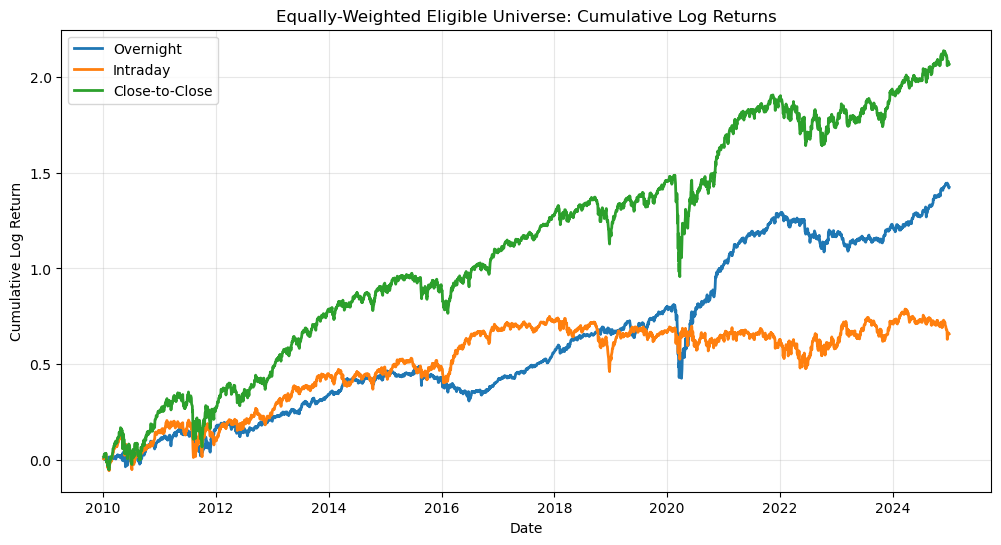

In [21]:
panel = df[
    (df["in_universe"] == 1) &
    (df["date"] >= "2010-01-01") &
    df["r_on"].notna() &
    df["r_id"].notna() &
    df["r_cc"].notna()
].copy()

# 先按天对“普通收益”做等权平均
daily_ew = panel.groupby("date", as_index=False).agg(
    ew_r_on=("r_on", "mean"),
    ew_r_id=("r_id", "mean"),
    ew_r_cc=("r_cc", "mean")
)

daily_ew = daily_ew.sort_values("date").copy()

# 再对“组合日收益”取对数
daily_ew["log_ew_r_on"] = np.log1p(daily_ew["ew_r_on"])
daily_ew["log_ew_r_id"] = np.log1p(daily_ew["ew_r_id"])
daily_ew["log_ew_r_cc"] = np.log1p(daily_ew["ew_r_cc"])

# 累计对数收益
daily_ew["cum_log_on"] = daily_ew["log_ew_r_on"].cumsum()
daily_ew["cum_log_id"] = daily_ew["log_ew_r_id"].cumsum()
daily_ew["cum_log_cc"] = daily_ew["log_ew_r_cc"].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(daily_ew["date"], daily_ew["cum_log_on"], label="Overnight", linewidth=2)
plt.plot(daily_ew["date"], daily_ew["cum_log_id"], label="Intraday", linewidth=2)
plt.plot(daily_ew["date"], daily_ew["cum_log_cc"], label="Close-to-Close", linewidth=2)

plt.title("Equally-Weighted Eligible Universe: Cumulative Log Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

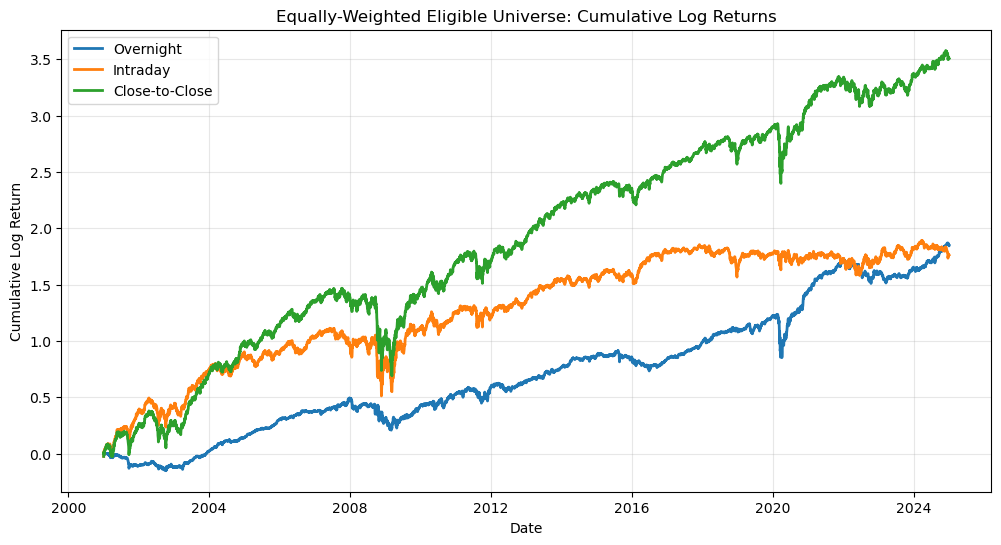

In [22]:
panel = df[
    (df["in_universe"] == 1) &
    (df["date"] >= "2000-01-01") &
    df["r_on"].notna() &
    df["r_id"].notna() &
    df["r_cc"].notna()
].copy()

# 先按天对“普通收益”做等权平均
daily_ew = panel.groupby("date", as_index=False).agg(
    ew_r_on=("r_on", "mean"),
    ew_r_id=("r_id", "mean"),
    ew_r_cc=("r_cc", "mean")
)

daily_ew = daily_ew.sort_values("date").copy()

# 再对“组合日收益”取对数
daily_ew["log_ew_r_on"] = np.log1p(daily_ew["ew_r_on"])
daily_ew["log_ew_r_id"] = np.log1p(daily_ew["ew_r_id"])
daily_ew["log_ew_r_cc"] = np.log1p(daily_ew["ew_r_cc"])

# 累计对数收益
daily_ew["cum_log_on"] = daily_ew["log_ew_r_on"].cumsum()
daily_ew["cum_log_id"] = daily_ew["log_ew_r_id"].cumsum()
daily_ew["cum_log_cc"] = daily_ew["log_ew_r_cc"].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(daily_ew["date"], daily_ew["cum_log_on"], label="Overnight", linewidth=2)
plt.plot(daily_ew["date"], daily_ew["cum_log_id"], label="Intraday", linewidth=2)
plt.plot(daily_ew["date"], daily_ew["cum_log_cc"], label="Close-to-Close", linewidth=2)

plt.title("Equally-Weighted Eligible Universe: Cumulative Log Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("231.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
# =========================
# Dispersion across years: equal-weighted portfolio
# =========================

yearly_ew = daily_ew.copy()
yearly_ew["year"] = yearly_ew["date"].dt.year

# annual cumulative log return by year
yearly_ew_stats = yearly_ew.groupby("year", as_index=False).agg(
    annual_on=("log_ew_r_on", "sum"),
    annual_id=("log_ew_r_id", "sum"),
    annual_cc=("log_ew_r_cc", "sum")
)

yearly_ew_stats

,year,annual_on,annual_id,annual_cc
0,2001,-0.108797,0.379928,0.250579
1,2002,-0.016891,0.032322,0.000266
2,2003,0.145128,0.330410,0.454614
3,2004,0.121341,0.158083,0.292723
4,2005,0.157982,-0.020117,0.127733
5,2006,0.078160,0.152492,0.226098
6,2007,0.111614,-0.073659,0.033310
7,2008,-0.175341,-0.137593,-0.329795
8,2009,0.110786,0.282116,0.385488
9,2010,0.100379,0.149733,0.248316


In [24]:
dispersion_ew = pd.DataFrame({
    "metric": ["mean", "std", "min", "max"],
    "overnight": [
        yearly_ew_stats["annual_on"].mean(),
        yearly_ew_stats["annual_on"].std(),
        yearly_ew_stats["annual_on"].min(),
        yearly_ew_stats["annual_on"].max(),
    ],
    "intraday": [
        yearly_ew_stats["annual_id"].mean(),
        yearly_ew_stats["annual_id"].std(),
        yearly_ew_stats["annual_id"].min(),
        yearly_ew_stats["annual_id"].max(),
    ],
    "close_to_close": [
        yearly_ew_stats["annual_cc"].mean(),
        yearly_ew_stats["annual_cc"].std(),
        yearly_ew_stats["annual_cc"].min(),
        yearly_ew_stats["annual_cc"].max(),
    ]
})
dispersion_ew = dispersion_ew.round(3)
dispersion_ew

,metric,overnight,intraday,close_to_close
0,mean,0.077,0.073,0.146
1,std,0.106,0.145,0.176
2,min,-0.175,-0.196,-0.330
3,max,0.261,0.380,0.455


In [25]:
# =====================================
# Equal-weighted annualised means
# =====================================
ew_sub = daily_ew.copy()
ew_sub["year"] = ew_sub["date"].dt.year
ew_sub["period"] = None

ew_sub.loc[ew_sub["year"].between(2001, 2009), "period"] = "2001-2009"
ew_sub.loc[ew_sub["year"].between(2010, 2024), "period"] = "2010-2024"

ew_sub = ew_sub.dropna(subset=["period"])

ew_annualised_mean = ew_sub.groupby("period", as_index=False).agg(
    overnight_ann_mean=("log_ew_r_on", lambda x: x.mean() * 252),
    intraday_ann_mean=("log_ew_r_id", lambda x: x.mean() * 252),
    close_to_close_ann_mean=("log_ew_r_cc", lambda x: x.mean() * 252)
)

ew_annualised_mean = ew_annualised_mean.round(3)
ew_annualised_mean

,period,overnight_ann_mean,intraday_ann_mean,close_to_close_ann_mean
0,2001-2009,0.047,0.123,0.160
1,2010-2024,0.095,0.044,0.138


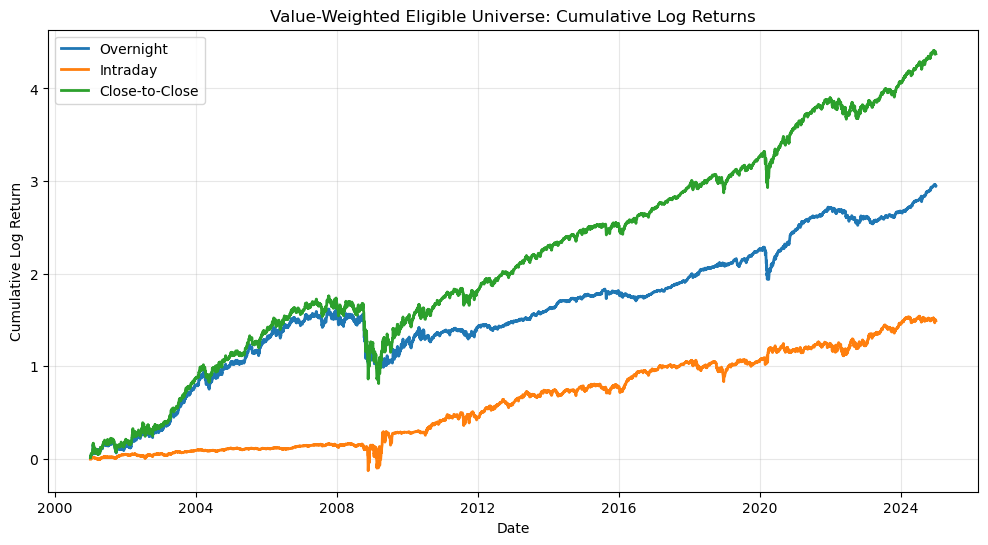

In [26]:
panel = df[
    (df["in_universe"] == 1) &
    (df["date"] >= "2000-01-01") &
    df["r_on"].notna() &
    df["r_id"].notna() &
    df["r_cc"].notna() &
    df["market_cap"].notna() &
    (df["market_cap"] > 0)
].copy()

daily_vw = (
    panel.groupby("date")
    .apply(lambda x: pd.Series({
        "vw_r_on": np.average(x["r_on"], weights=x["market_cap"]),
        "vw_r_id": np.average(x["r_id"], weights=x["market_cap"]),
        "vw_r_cc": np.average(x["r_cc"], weights=x["market_cap"]),
    }))
    .reset_index()
)

daily_vw = daily_vw.sort_values("date").copy()

daily_vw["log_vw_r_on"] = np.log1p(daily_vw["vw_r_on"])
daily_vw["log_vw_r_id"] = np.log1p(daily_vw["vw_r_id"])
daily_vw["log_vw_r_cc"] = np.log1p(daily_vw["vw_r_cc"])

daily_vw["cum_log_on"] = daily_vw["log_vw_r_on"].cumsum()
daily_vw["cum_log_id"] = daily_vw["log_vw_r_id"].cumsum()
daily_vw["cum_log_cc"] = daily_vw["log_vw_r_cc"].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(daily_vw["date"], daily_vw["cum_log_on"], label="Overnight", linewidth=2)
plt.plot(daily_vw["date"], daily_vw["cum_log_id"], label="Intraday", linewidth=2)
plt.plot(daily_vw["date"], daily_vw["cum_log_cc"], label="Close-to-Close", linewidth=2)

plt.title("Value-Weighted Eligible Universe: Cumulative Log Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("232.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
yearly_vw = daily_vw.copy()
yearly_vw["year"] = yearly_vw["date"].dt.year

yearly_vw_stats = yearly_vw.groupby("year", as_index=False).agg(
    annual_on=("log_vw_r_on", "sum"),
    annual_id=("log_vw_r_id", "sum"),
    annual_cc=("log_vw_r_cc", "sum")
)

dispersion_vw = pd.DataFrame({
    "metric": ["mean", "std", "min", "max"],
    "overnight": [
        yearly_vw_stats["annual_on"].mean(),
        yearly_vw_stats["annual_on"].std(),
        yearly_vw_stats["annual_on"].min(),
        yearly_vw_stats["annual_on"].max(),
    ],
    "intraday": [
        yearly_vw_stats["annual_id"].mean(),
        yearly_vw_stats["annual_id"].std(),
        yearly_vw_stats["annual_id"].min(),
        yearly_vw_stats["annual_id"].max(),
    ],
    "close_to_close": [
        yearly_vw_stats["annual_cc"].mean(),
        yearly_vw_stats["annual_cc"].std(),
        yearly_vw_stats["annual_cc"].min(),
        yearly_vw_stats["annual_cc"].max(),
    ]
})
dispersion_vw = dispersion_vw.round(3)
dispersion_vw

,metric,overnight,intraday,close_to_close
0,mean,0.123,0.062,0.182
1,std,0.162,0.080,0.185
2,min,-0.417,-0.136,-0.440
3,max,0.486,0.223,0.528


In [28]:
# =====================================
# Value-weighted annualised means
# =====================================
vw_sub = daily_vw.copy()
vw_sub["year"] = vw_sub["date"].dt.year
vw_sub["period"] = None

vw_sub.loc[vw_sub["year"].between(2001, 2009), "period"] = "2001-2009"
vw_sub.loc[vw_sub["year"].between(2010, 2024), "period"] = "2010-2024"

vw_sub = vw_sub.dropna(subset=["period"])

vw_annualised_mean = vw_sub.groupby("period", as_index=False).agg(
    overnight_ann_mean=("log_vw_r_on", lambda x: x.mean() * 252),
    intraday_ann_mean=("log_vw_r_id", lambda x: x.mean() * 252),
    close_to_close_ann_mean=("log_vw_r_cc", lambda x: x.mean() * 252)
)

vw_annualised_mean = vw_annualised_mean.round(3)
vw_annualised_mean

,period,overnight_ann_mean,intraday_ann_mean,close_to_close_ann_mean
0,2001-2009,0.142,0.032,0.169
1,2010-2024,0.112,0.081,0.191


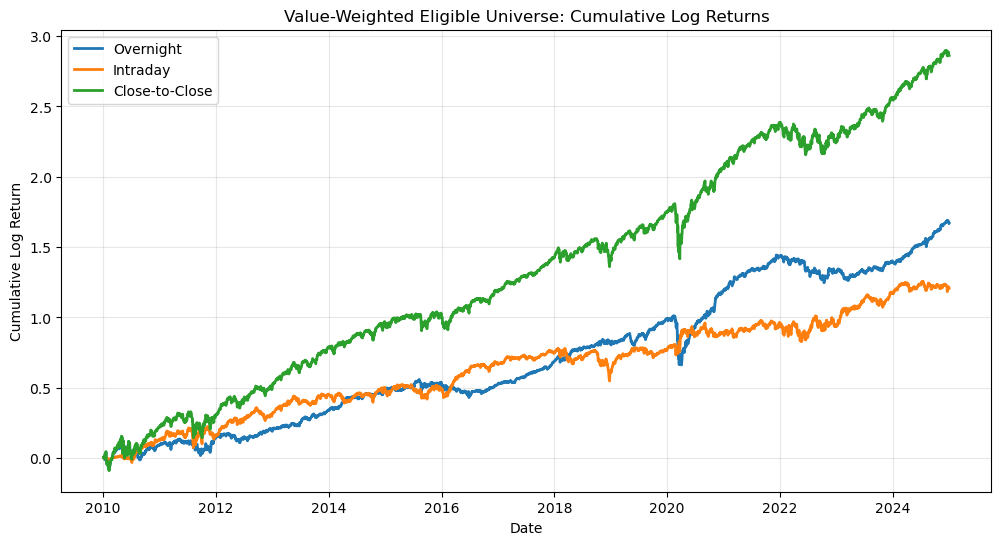

In [29]:
panel = df[
    (df["in_universe"] == 1) &
    (df["date"] >= "2010-01-01") &
    df["r_on"].notna() &
    df["r_id"].notna() &
    df["r_cc"].notna() &
    df["market_cap"].notna() &
    (df["market_cap"] > 0)
].copy()

daily_vw = (
    panel.groupby("date")
    .apply(lambda x: pd.Series({
        "vw_r_on": np.average(x["r_on"], weights=x["market_cap"]),
        "vw_r_id": np.average(x["r_id"], weights=x["market_cap"]),
        "vw_r_cc": np.average(x["r_cc"], weights=x["market_cap"]),
    }))
    .reset_index()
)

daily_vw = daily_vw.sort_values("date").copy()

daily_vw["log_vw_r_on"] = np.log1p(daily_vw["vw_r_on"])
daily_vw["log_vw_r_id"] = np.log1p(daily_vw["vw_r_id"])
daily_vw["log_vw_r_cc"] = np.log1p(daily_vw["vw_r_cc"])

daily_vw["cum_log_on"] = daily_vw["log_vw_r_on"].cumsum()
daily_vw["cum_log_id"] = daily_vw["log_vw_r_id"].cumsum()
daily_vw["cum_log_cc"] = daily_vw["log_vw_r_cc"].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(daily_vw["date"], daily_vw["cum_log_on"], label="Overnight", linewidth=2)
plt.plot(daily_vw["date"], daily_vw["cum_log_id"], label="Intraday", linewidth=2)
plt.plot(daily_vw["date"], daily_vw["cum_log_cc"], label="Close-to-Close", linewidth=2)

plt.title("Value-Weighted Eligible Universe: Cumulative Log Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()